**EXPLORATORY DATA ANALYSIS(EDA)**

**EDA is organized as follows**

**1:**  Data Loading

**2:** Summary Statistics

**3:** Salary vs Performance (H1)

**4:** Age vs Performance (H2)

**5:** Changing in Salary vs Performance (H3)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 140
plt.rcParams['font.size'] = 10
sns.set_theme(style="whitegrid", palette="muted")

**DATA LOADING**

In [39]:
df = pd.read_csv("NBA_Advanced_Salary_Data.csv")

df = df.drop(columns=['Unnamed: 0', 'Rk', 'Awards', 'Player-additional'], errors='ignore')

df = df[df['G'] >= 20].copy() # minimum 20 plays

df['Salary_M'] = df['Salary'] / 1e6
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[18, 23, 27, 31, 99],
                          labels=['18-23', '24-27', '28-31', '32+'])
df['Salary_Group'] = pd.qcut(df['Salary_M'], q=3, labels=['Low', 'Mid', 'High'])

# Split by the seasons
s22 = df[df['Season'] == '2022-23'].copy()
s24 = df[df['Season'] == '2023-24'].copy()

# Players appearing in both seasons (for H3)
both = s22[['Player_Clean', 'VORP', 'PER', 'WS', 'Salary_M']].merge(
    s24[['Player_Clean', 'VORP', 'PER', 'WS', 'Salary_M']],
    on='Player_Clean', suffixes=('_22', '_24'))
both['VORP_change']   = both['VORP_24']     - both['VORP_22']
both['PER_change']    = both['PER_24']      - both['PER_22']
both['Salary_change'] = both['Salary_M_24'] - both['Salary_M_22']

pal = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

**DESCRIPTIVE STATISTICS**

In [40]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
desc_cols = ['Age', 'PER', 'TS%', 'WS', 'BPM', 'VORP', 'Salary_M']
print(df[desc_cols].describe().round(2).to_string())
print(f"\nPlayers per season — 2022-23: {len(s22)}, 2023-24: {len(s24)}")
print(f"Median salary : ${df['Salary'].median():,.0f}")
print(f"Mean PER      : {df['PER'].mean():.2f}")
print(f"Mean VORP     : {df['VORP'].mean():.2f}")

DESCRIPTIVE STATISTICS
          Age     PER     TS%      WS     BPM    VORP  Salary_M
count  751.00  751.00  751.00  751.00  751.00  751.00    751.00
mean    26.22   13.93    0.57    2.93   -0.75    0.71      9.84
std      4.27    4.52    0.06    2.59    2.85    1.29     11.48
min     19.00   -2.00    0.00   -1.60   -9.60   -1.50      0.00
25%     23.00   10.80    0.54    0.90   -2.60   -0.10      2.00
50%     25.00   13.40    0.57    2.30   -1.00    0.30      5.01
75%     29.00   16.50    0.61    4.30    0.80    1.10     12.98
max     39.00   34.10    0.78   14.60   11.60    7.20     51.92

Players per season — 2022-23: 396, 2023-24: 355
Median salary : $5,009,633
Mean PER      : 13.93
Mean VORP     : 0.71


**Salary vs Performance (H1)**

Data was filtered for players with G≥20 to ensure reliability.

The positive slope of the regression line indicates that there is a significant relationship between players' salaries and performance.

However, while the correlation is positive, we observe higher variance in the "Star Player" zone (PER > 22). This suggests that for elite players, salary is influenced not only by efficiency but also by factors like market value and contract seniority.


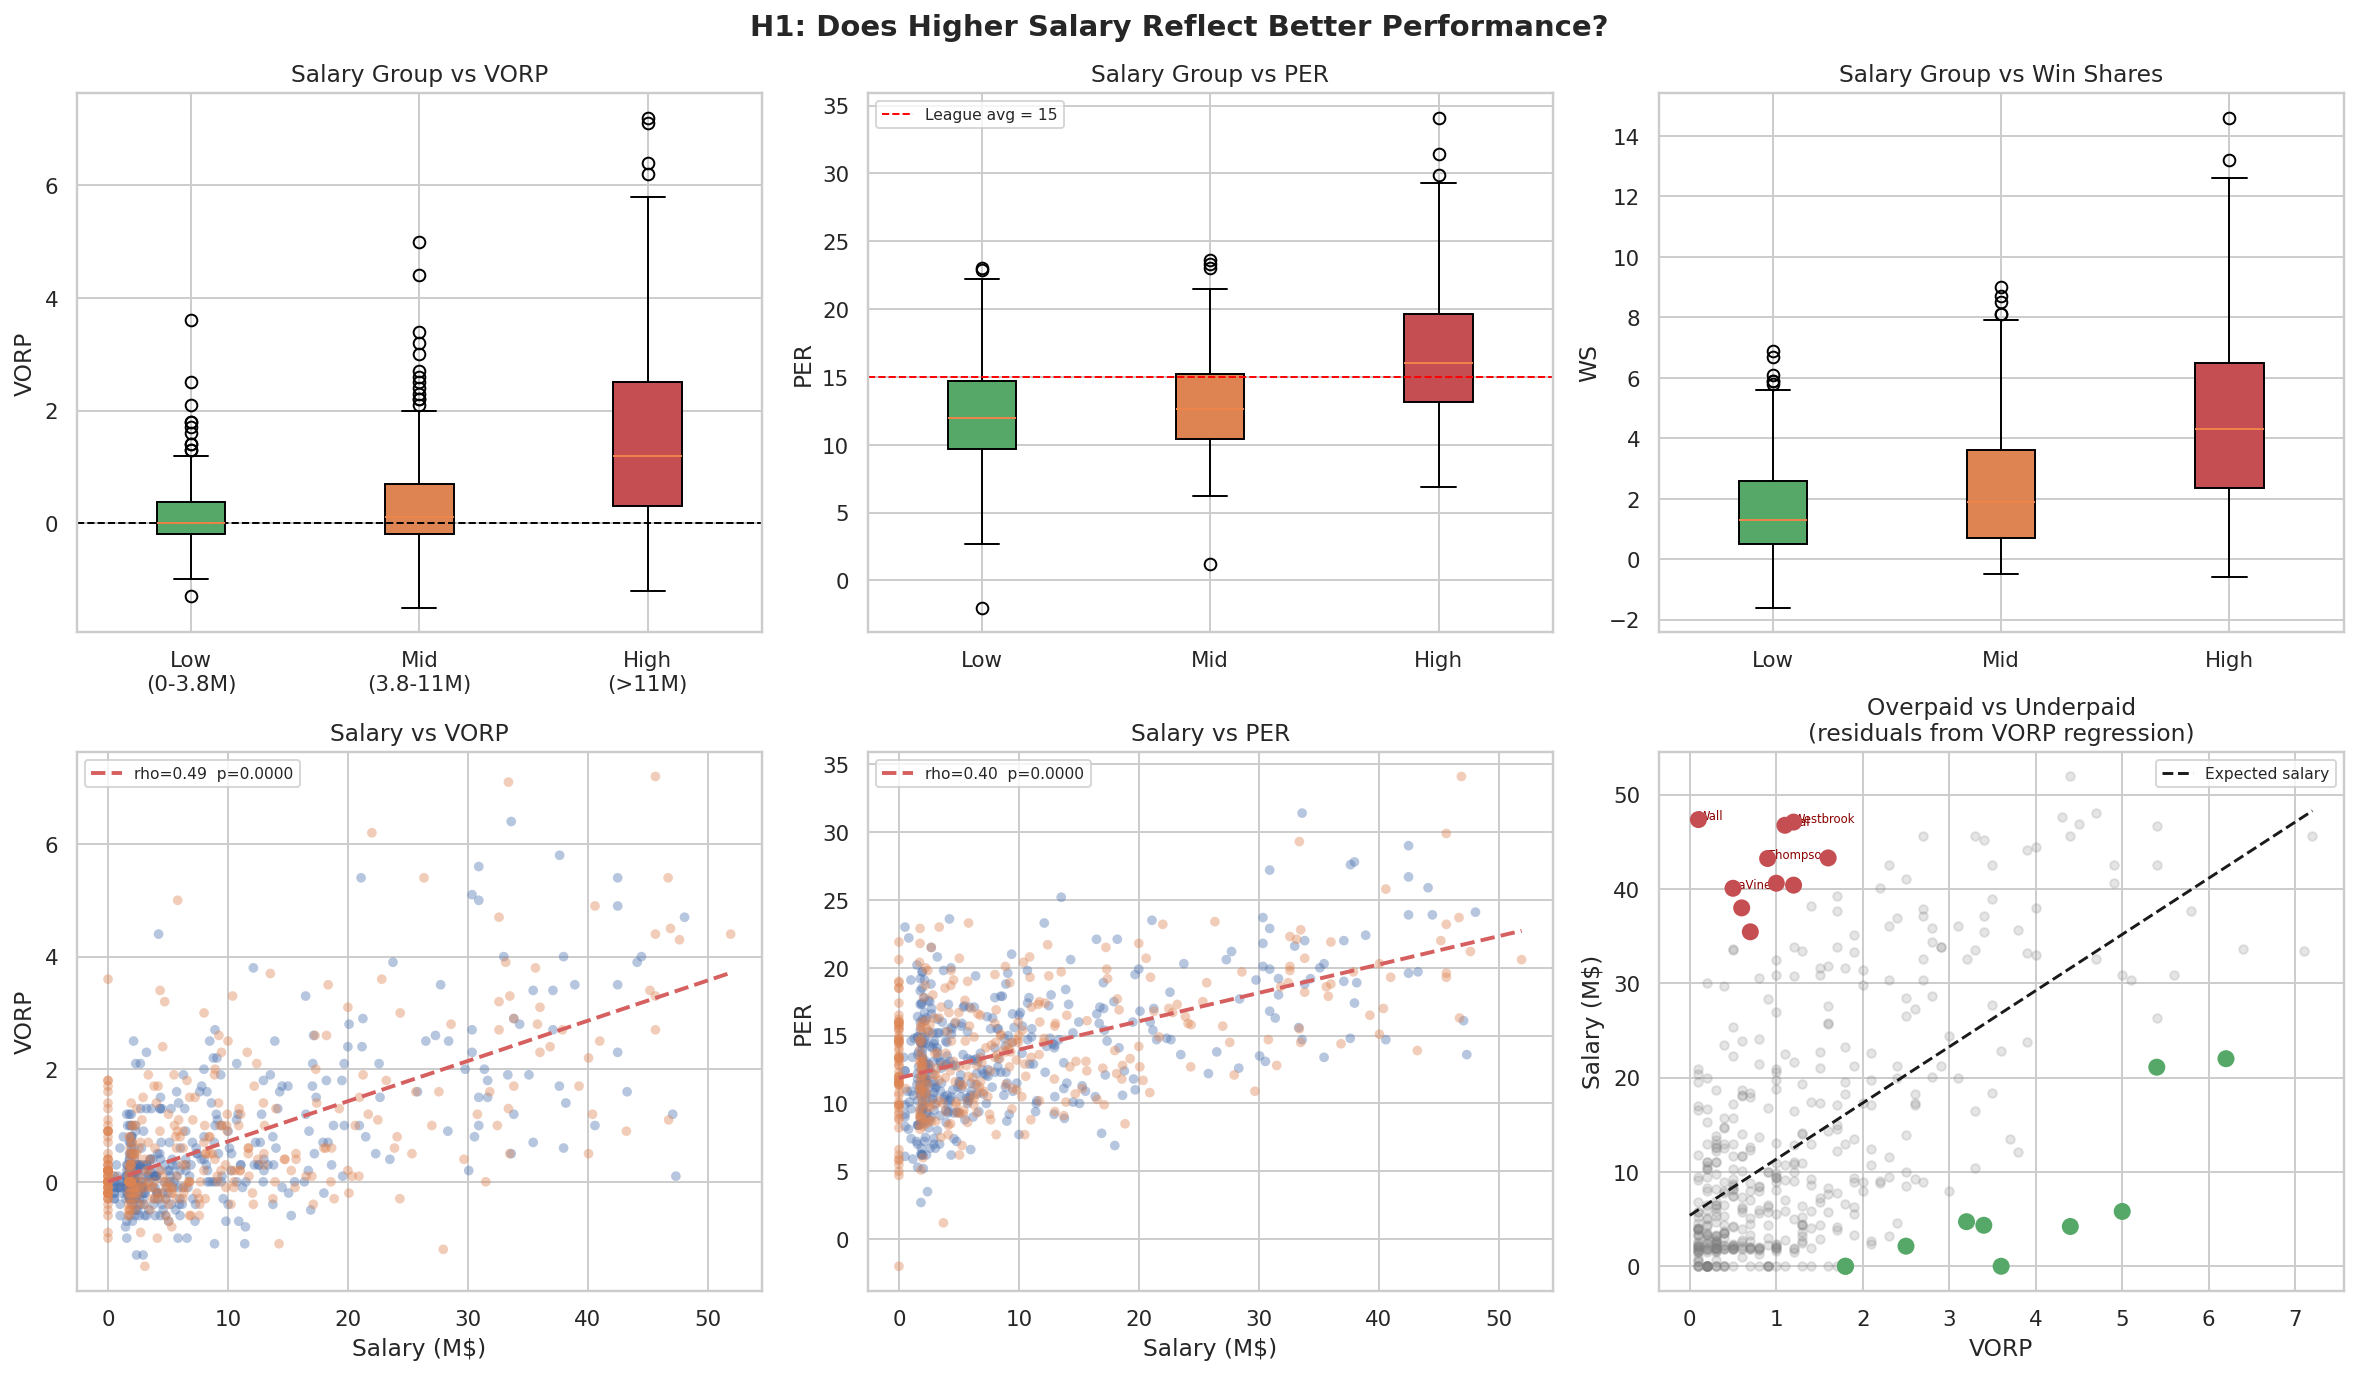

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('H1: Does Higher Salary Reflect Better Performance?',
             fontsize=15, fontweight='bold')

ax = axes[0, 0]
groups_vorp = [df[df['Salary_Group'] == g]['VORP'].dropna() for g in ['Low', 'Mid', 'High']]
bp = ax.boxplot(groups_vorp,
                labels=['Low\n(0-3.8M)', 'Mid\n(3.8-11M)', 'High\n(>11M)'],
                patch_artist=True)
for patch, c in zip(bp['boxes'], ['#55A868', '#DD8452', '#C44E52']):
    patch.set_facecolor(c)
ax.axhline(0, color='black', ls='--', lw=1)
ax.set_title('Salary Group vs VORP'); ax.set_ylabel('VORP')

ax = axes[0, 1]
groups_per = [df[df['Salary_Group'] == g]['PER'].dropna() for g in ['Low', 'Mid', 'High']]
bp = ax.boxplot(groups_per, labels=['Low', 'Mid', 'High'], patch_artist=True)
for patch, c in zip(bp['boxes'], ['#55A868', '#DD8452', '#C44E52']):
    patch.set_facecolor(c)
ax.axhline(15, color='red', ls='--', lw=1, label='League avg = 15')
ax.set_title('Salary Group vs PER'); ax.set_ylabel('PER'); ax.legend(fontsize=8)

ax = axes[0, 2]
groups_ws = [df[df['Salary_Group'] == g]['WS'].dropna() for g in ['Low', 'Mid', 'High']]
bp = ax.boxplot(groups_ws, labels=['Low', 'Mid', 'High'], patch_artist=True)
for patch, c in zip(bp['boxes'], ['#55A868', '#DD8452', '#C44E52']):
    patch.set_facecolor(c)
ax.set_title('Salary Group vs Win Shares'); ax.set_ylabel('WS')

ax = axes[1, 0]
tmp = df[['Salary_M', 'VORP', 'Season']].dropna()
colors = tmp['Season'].map({'2022-23': '#4C72B0', '2023-24': '#DD8452'})
ax.scatter(tmp['Salary_M'], tmp['VORP'], c=colors, alpha=0.4, s=25, edgecolors='none')
r, p = stats.spearmanr(tmp['Salary_M'], tmp['VORP'])
m, b, _, _, _ = stats.linregress(tmp['Salary_M'], tmp['VORP'])
xs = np.linspace(0, tmp['Salary_M'].max(), 200)
ax.plot(xs, m * xs + b, 'r--', lw=2, label=f'rho={r:.2f}  p={p:.4f}')
ax.set_title('Salary vs VORP')
ax.set_xlabel('Salary (M$)'); ax.set_ylabel('VORP'); ax.legend(fontsize=8)

ax = axes[1, 1]
tmp2 = df[['Salary_M', 'PER', 'Season']].dropna()
colors2 = tmp2['Season'].map({'2022-23': '#4C72B0', '2023-24': '#DD8452'})
ax.scatter(tmp2['Salary_M'], tmp2['PER'], c=colors2, alpha=0.4, s=25, edgecolors='none')
r2, p2 = stats.spearmanr(tmp2['Salary_M'], tmp2['PER'])
m2, b2, _, _, _ = stats.linregress(tmp2['Salary_M'], tmp2['PER'])
xs2 = np.linspace(0, tmp2['Salary_M'].max(), 200)
ax.plot(xs2, m2 * xs2 + b2, 'r--', lw=2, label=f'rho={r2:.2f}  p={p2:.4f}')
ax.set_title('Salary vs PER')
ax.set_xlabel('Salary (M$)'); ax.set_ylabel('PER'); ax.legend(fontsize=8)

ax = axes[1, 2]
tmp3 = df[df['VORP'] > 0][['Player_Clean', 'Salary_M', 'VORP']].dropna().copy()
m3, b3, _, _, _ = stats.linregress(tmp3['VORP'], tmp3['Salary_M'])
tmp3['Expected_Salary'] = m3 * tmp3['VORP'] + b3
tmp3['Residual']        = tmp3['Salary_M'] - tmp3['Expected_Salary']
overpaid  = tmp3.nlargest(10, 'Residual')
underpaid = tmp3.nsmallest(10, 'Residual')
highlight = pd.concat([overpaid, underpaid])
colors_h  = ['#C44E52' if r > 0 else '#55A868' for r in highlight['Residual']]
ax.scatter(tmp3['VORP'], tmp3['Salary_M'], alpha=0.2, s=20, color='gray')
ax.scatter(highlight['VORP'], highlight['Salary_M'], c=colors_h, s=60, zorder=5)
xs3 = np.linspace(0, tmp3['VORP'].max(), 200)
ax.plot(xs3, m3 * xs3 + b3, 'k--', lw=1.5, label='Expected salary')
for _, row in overpaid.head(5).iterrows():
    ax.annotate(row['Player_Clean'].split()[-1],
                (row['VORP'], row['Salary_M']), fontsize=6, color='darkred')
ax.set_title('Overpaid vs Underpaid\n(residuals from VORP regression)')
ax.set_xlabel('VORP'); ax.set_ylabel('Salary (M$)'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig2_h1_salary_performance.png', bbox_inches='tight')
plt.show()

**Age vs Performance (H2)**

**Observation:** The scatter plot reveals a "performance peak" between ages 24 and 28. While there is a slight downward trend in the regression line as age increases, elite outliers remain highly efficient even after age 30.

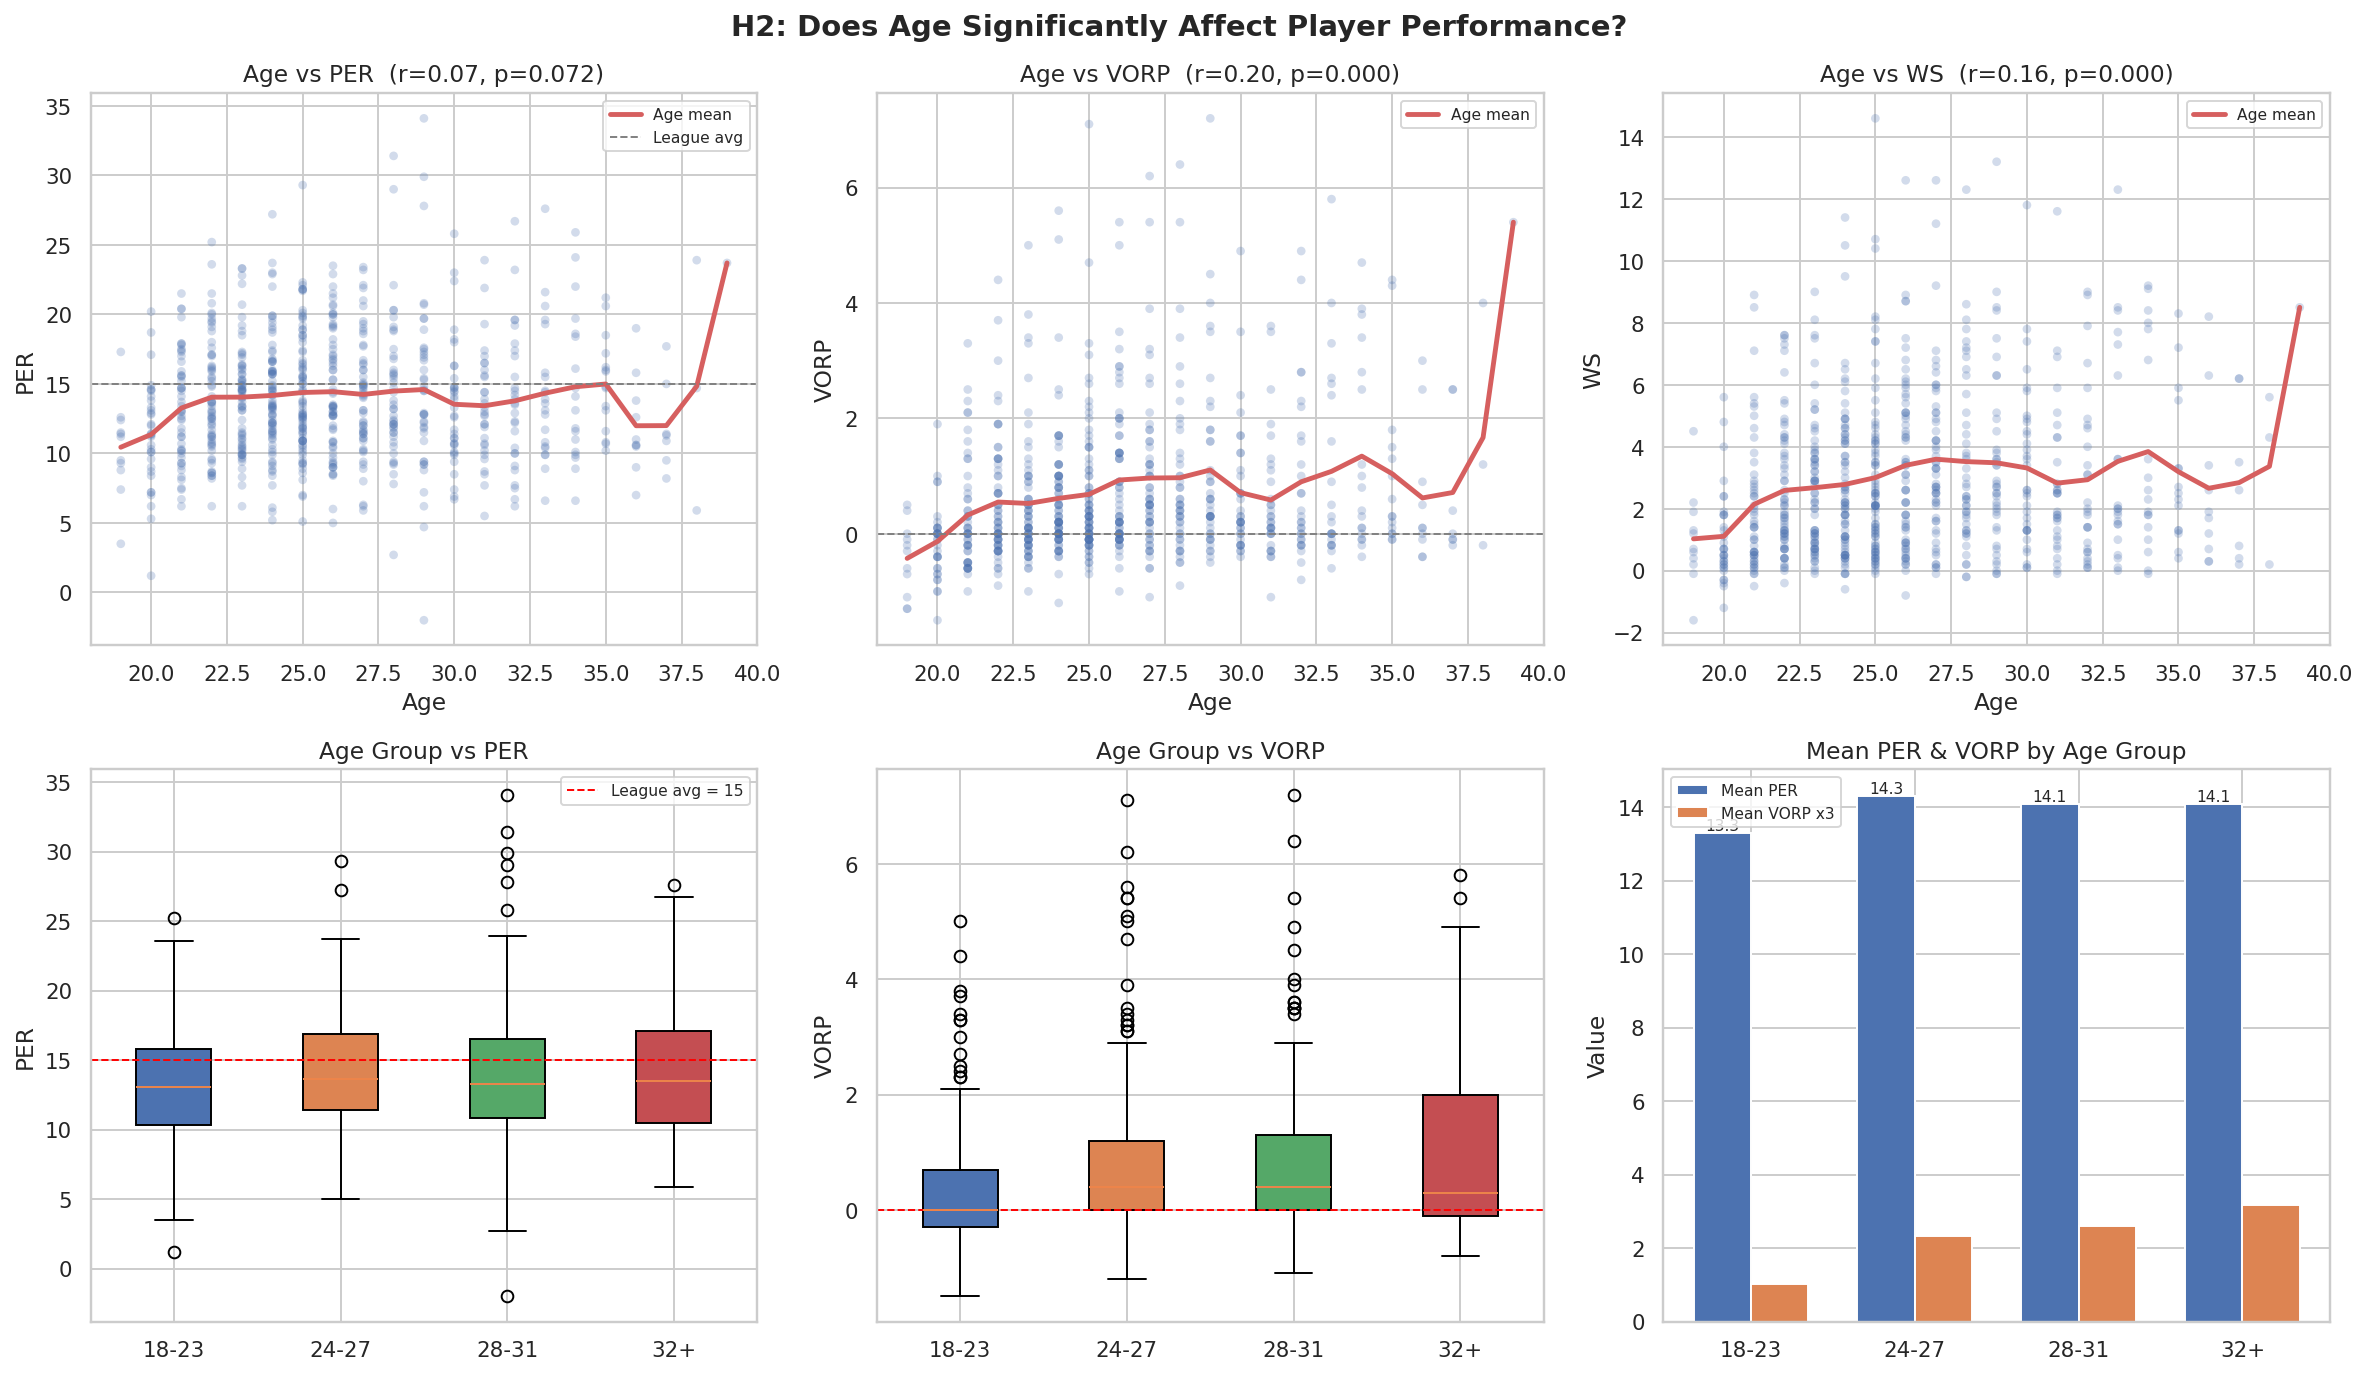

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('H2: Does Age Significantly Affect Player Performance?',
             fontsize=15, fontweight='bold')

age_bins = range(19, 43)

ax = axes[0, 0]
tmp = df[['Age', 'PER']].dropna()
ax.scatter(tmp['Age'], tmp['PER'], alpha=0.25, s=20, color='#4C72B0', edgecolors='none')
means = [tmp[tmp['Age'] == a]['PER'].mean() for a in age_bins]
valid = [(a, m) for a, m in zip(age_bins, means) if not np.isnan(m)]
ax.plot([v[0] for v in valid], [v[1] for v in valid], 'r-', lw=2.5, label='Age mean')
ax.axhline(15, color='gray', ls='--', lw=1, label='League avg')
r, p = stats.pearsonr(tmp['Age'], tmp['PER'])
ax.set_title(f'Age vs PER  (r={r:.2f}, p={p:.3f})')
ax.set_xlabel('Age'); ax.set_ylabel('PER'); ax.legend(fontsize=8)

ax = axes[0, 1]
tmp = df[['Age', 'VORP']].dropna()
ax.scatter(tmp['Age'], tmp['VORP'], alpha=0.25, s=20, color='#4C72B0', edgecolors='none')
means = [tmp[tmp['Age'] == a]['VORP'].mean() for a in age_bins]
valid = [(a, m) for a, m in zip(age_bins, means) if not np.isnan(m)]
ax.plot([v[0] for v in valid], [v[1] for v in valid], 'r-', lw=2.5, label='Age mean')
ax.axhline(0, color='gray', ls='--', lw=1)
r, p = stats.pearsonr(tmp['Age'], tmp['VORP'])
ax.set_title(f'Age vs VORP  (r={r:.2f}, p={p:.3f})')
ax.set_xlabel('Age'); ax.set_ylabel('VORP'); ax.legend(fontsize=8)

ax = axes[0, 2]
tmp = df[['Age', 'WS']].dropna()
ax.scatter(tmp['Age'], tmp['WS'], alpha=0.25, s=20, color='#4C72B0', edgecolors='none')
means = [tmp[tmp['Age'] == a]['WS'].mean() for a in age_bins]
valid = [(a, m) for a, m in zip(age_bins, means) if not np.isnan(m)]
ax.plot([v[0] for v in valid], [v[1] for v in valid], 'r-', lw=2.5, label='Age mean')
r, p = stats.pearsonr(tmp['Age'], tmp['WS'])
ax.set_title(f'Age vs WS  (r={r:.2f}, p={p:.3f})')
ax.set_xlabel('Age'); ax.set_ylabel('WS'); ax.legend(fontsize=8)


ax = axes[1, 0]
age_group_labels = ['18-23', '24-27', '28-31', '32+']
groups_per = [df[df['Age_Group'] == g]['PER'].dropna() for g in age_group_labels]
bp = ax.boxplot(groups_per, labels=age_group_labels, patch_artist=True)
for patch, c in zip(bp['boxes'], pal[:4]): patch.set_facecolor(c)
ax.axhline(15, color='red', ls='--', lw=1, label='League avg = 15')
ax.set_title('Age Group vs PER'); ax.set_ylabel('PER'); ax.legend(fontsize=8)

ax = axes[1, 1]
groups_vorp = [df[df['Age_Group'] == g]['VORP'].dropna() for g in age_group_labels]
bp = ax.boxplot(groups_vorp, labels=age_group_labels, patch_artist=True)
for patch, c in zip(bp['boxes'], pal[:4]): patch.set_facecolor(c)
ax.axhline(0, color='red', ls='--', lw=1)
ax.set_title('Age Group vs VORP'); ax.set_ylabel('VORP')

ax = axes[1, 2]
age_per  = df.groupby('Age_Group', observed=True)['PER'].mean()
age_vorp = df.groupby('Age_Group', observed=True)['VORP'].mean()
x = np.arange(len(age_group_labels))
w = 0.35
bars1 = ax.bar(x - w / 2, age_per.values,      w, label='Mean PER',    color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + w / 2, age_vorp.values * 3, w, label='Mean VORP x3', color='#DD8452', edgecolor='white')
ax.bar_label(bars1, fmt='%.1f', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(age_group_labels)
ax.set_title('Mean PER & VORP by Age Group')
ax.set_ylabel('Value'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig3_h2_age_performance.png', bbox_inches='tight')
plt.show()

**Changing in Salary vs Performance (H3)**

This analysis exclusively includes players who were active in both the 2022-23 and 2023-24 seasons.

**Observation:**  The consistency of high-end outliers confirms that elite players maintain their financial status across seasons, while the overall "middle class" of the NBA also experienced a slight increase in compensation.


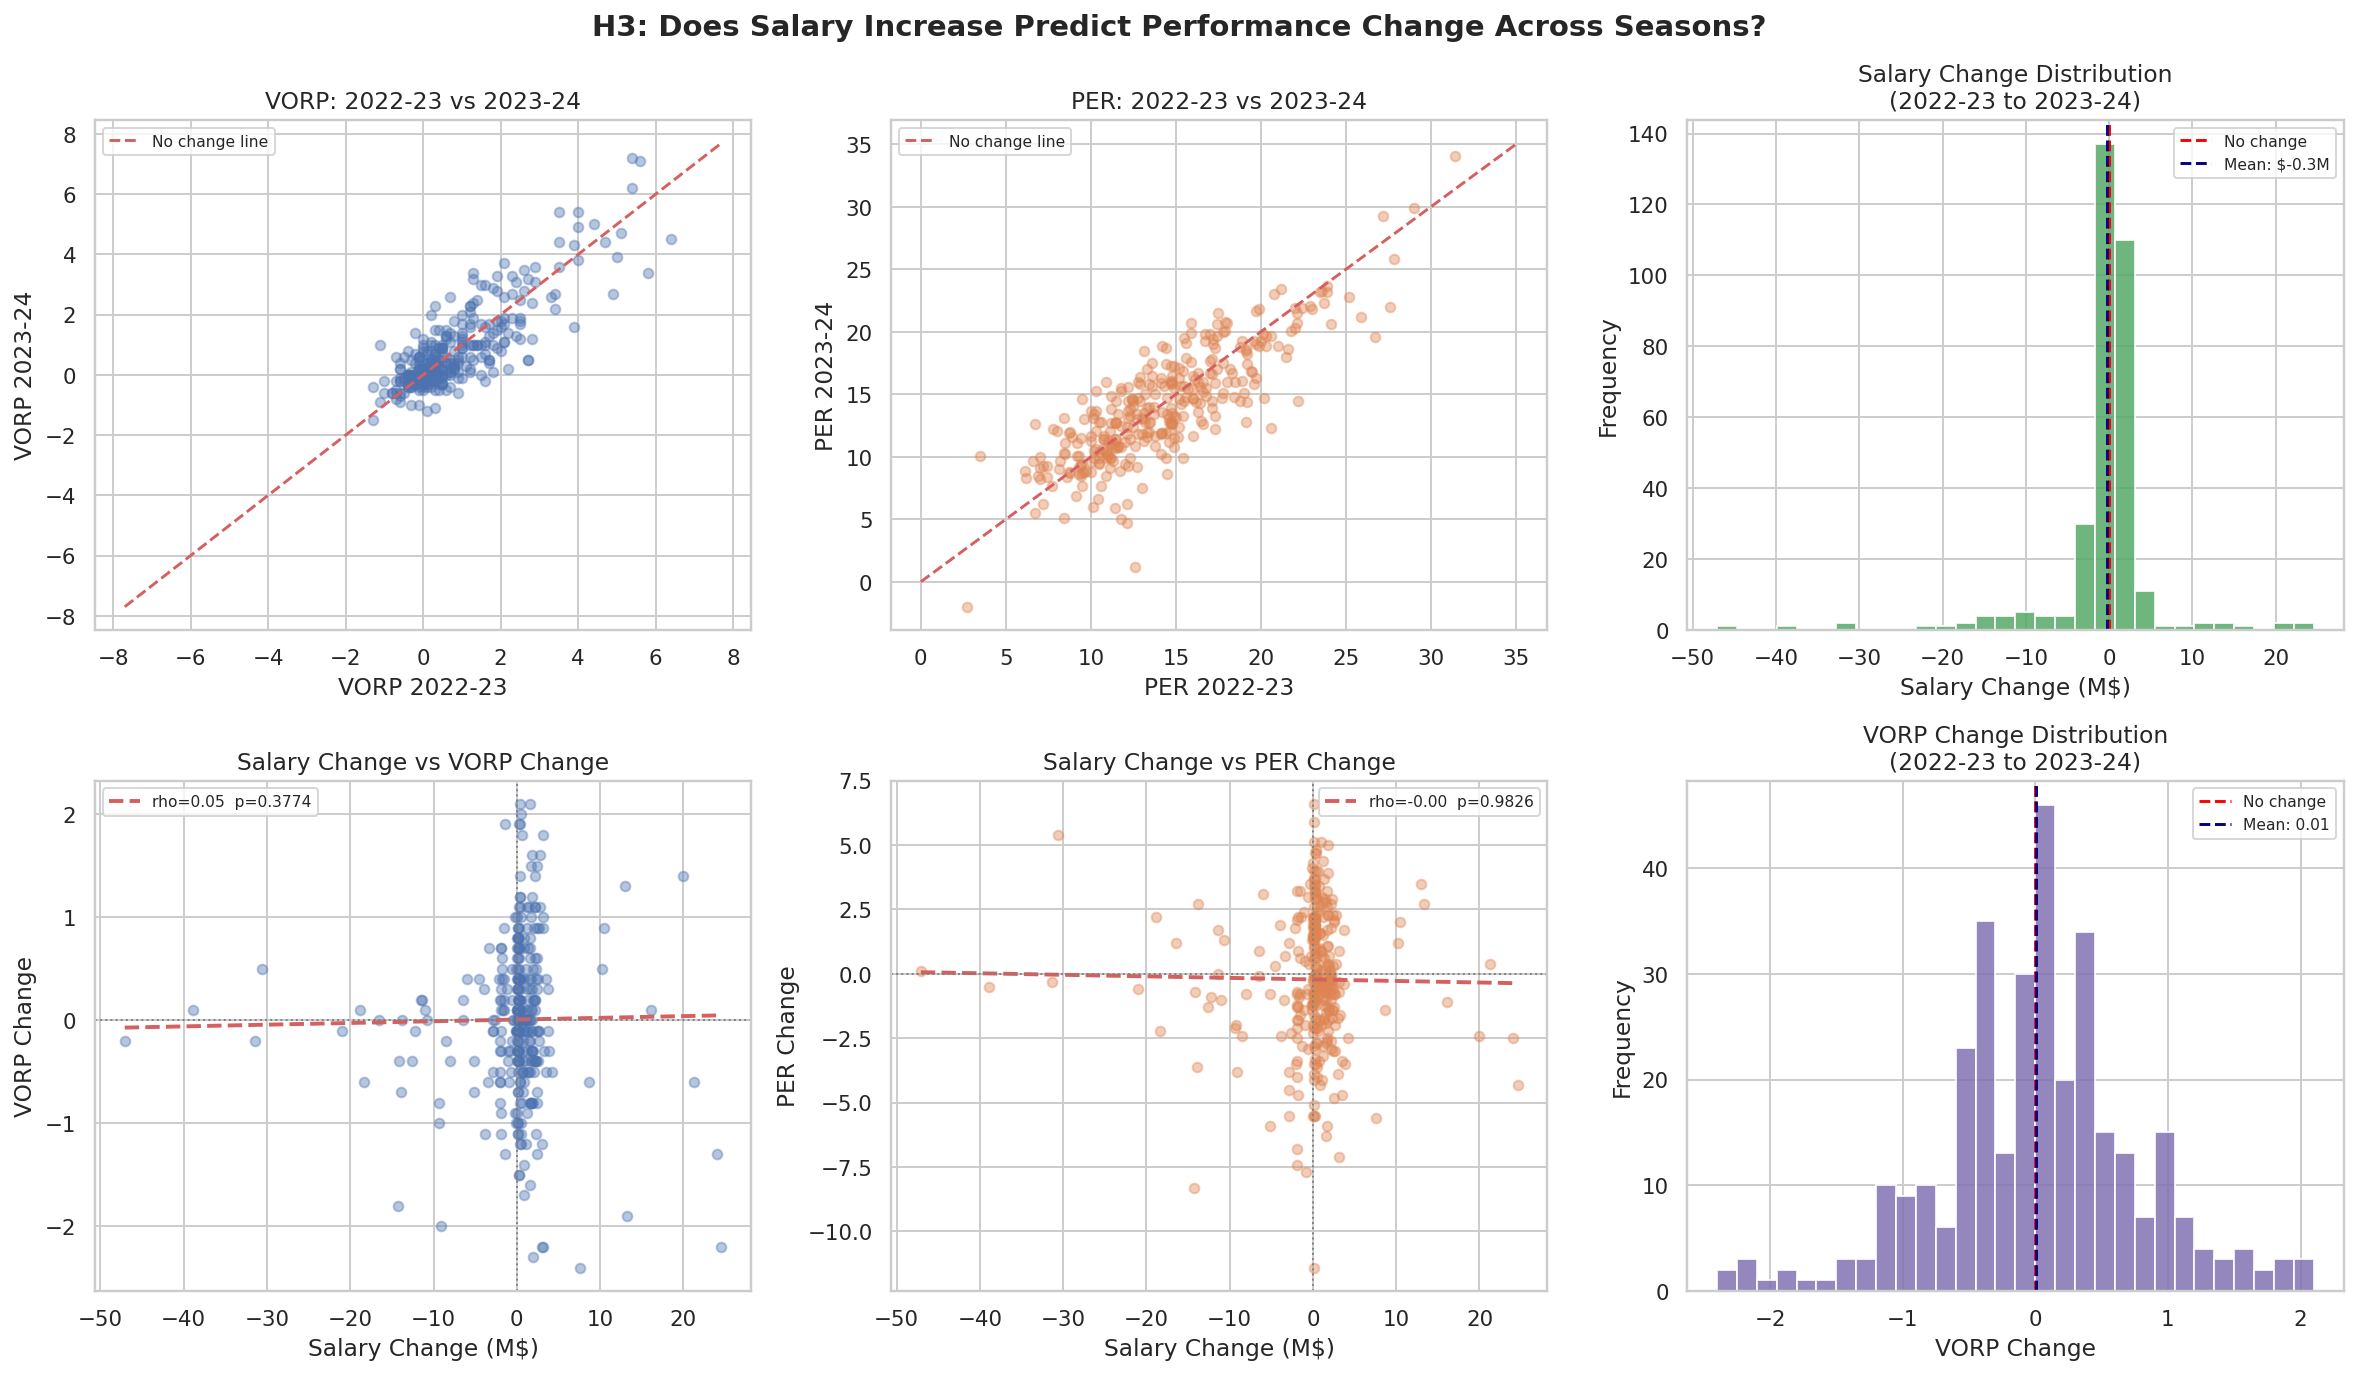

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('H3: Does Salary Increase Predict Performance Change Across Seasons?',
             fontsize=15, fontweight='bold')

ax = axes[0, 0]
ax.scatter(both['VORP_22'], both['VORP_24'], alpha=0.4, s=25, color='#4C72B0')
lim = max(both['VORP_22'].abs().max(), both['VORP_24'].abs().max()) + 0.5
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='No change line')
ax.set_title('VORP: 2022-23 vs 2023-24')
ax.set_xlabel('VORP 2022-23'); ax.set_ylabel('VORP 2023-24'); ax.legend(fontsize=8)

ax = axes[0, 1]
ax.scatter(both['PER_22'], both['PER_24'], alpha=0.4, s=25, color='#DD8452')
lim2 = max(both['PER_22'].max(), both['PER_24'].max()) + 1
ax.plot([0, lim2], [0, lim2], 'r--', lw=1.5, label='No change line')
ax.set_title('PER: 2022-23 vs 2023-24')
ax.set_xlabel('PER 2022-23'); ax.set_ylabel('PER 2023-24'); ax.legend(fontsize=8)

ax = axes[0, 2]
ax.hist(both['Salary_change'], bins=30, color='#55A868', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', ls='--', lw=1.5, label='No change')
ax.axvline(both['Salary_change'].mean(), color='navy', ls='--', lw=1.5,
           label=f'Mean: ${both["Salary_change"].mean():.1f}M')
ax.set_title('Salary Change Distribution\n(2022-23 to 2023-24)')
ax.set_xlabel('Salary Change (M$)'); ax.set_ylabel('Frequency'); ax.legend(fontsize=8)

ax = axes[1, 0]
tmp = both[['Salary_change', 'VORP_change']].dropna()
ax.scatter(tmp['Salary_change'], tmp['VORP_change'], alpha=0.4, s=25, color='#4C72B0')
r, p = stats.spearmanr(tmp['Salary_change'], tmp['VORP_change'])
m, b, _, _, _ = stats.linregress(tmp['Salary_change'], tmp['VORP_change'])
xs = np.linspace(tmp['Salary_change'].min(), tmp['Salary_change'].max(), 200)
ax.plot(xs, m * xs + b, 'r--', lw=2, label=f'rho={r:.2f}  p={p:.4f}')
ax.axhline(0, color='gray', ls=':', lw=1)
ax.axvline(0, color='gray', ls=':', lw=1)
ax.set_title('Salary Change vs VORP Change')
ax.set_xlabel('Salary Change (M$)'); ax.set_ylabel('VORP Change'); ax.legend(fontsize=8)

ax = axes[1, 1]
tmp2 = both[['Salary_change', 'PER_change']].dropna()
ax.scatter(tmp2['Salary_change'], tmp2['PER_change'], alpha=0.4, s=25, color='#DD8452')
r2, p2 = stats.spearmanr(tmp2['Salary_change'], tmp2['PER_change'])
m2, b2, _, _, _ = stats.linregress(tmp2['Salary_change'], tmp2['PER_change'])
xs2 = np.linspace(tmp2['Salary_change'].min(), tmp2['Salary_change'].max(), 200)
ax.plot(xs2, m2 * xs2 + b2, 'r--', lw=2, label=f'rho={r2:.2f}  p={p2:.4f}')
ax.axhline(0, color='gray', ls=':', lw=1)
ax.axvline(0, color='gray', ls=':', lw=1)
ax.set_title('Salary Change vs PER Change')
ax.set_xlabel('Salary Change (M$)'); ax.set_ylabel('PER Change'); ax.legend(fontsize=8)

ax = axes[1, 2]
ax.hist(both['VORP_change'], bins=30, color='#8172B2', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', ls='--', lw=1.5, label='No change')
ax.axvline(both['VORP_change'].mean(), color='navy', ls='--', lw=1.5,
           label=f'Mean: {both["VORP_change"].mean():.2f}')
ax.set_title('VORP Change Distribution\n(2022-23 to 2023-24)')
ax.set_xlabel('VORP Change'); ax.set_ylabel('Frequency'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig4_h3_salary_change.png', bbox_inches='tight')
plt.show()